In [2]:
#-----------------------------------------------------------------------------------------
# @Autor: Aurélien Vannieuwenhuyze
# @Empresa: Junior Makers Place
# @Libro: Inteligencia Artificial Fácil
# @Capí­tulo : 08 - Opiniones y clasificación de textos
#
# Módulos necesarios, versión mínima:
#   PANDAS 0.24.2
#   NUMPY 1.16.3
#   SCIKIT-LEARN : 0.21.0
#   NLTK : 3.4
#
#-----------------------------------------------------------------------------------------

#Carga del archivo
import pandas as pd
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
#from google.colab import files

In [4]:
# Cargar dataset
mensajesTwitter = pd.read_csv("https://github.com/palasatenea66/DATASETS/raw/main/calentamientoClimatico.csv", delimiter=";")
# Información sobre la cantidad de observaciones y su contenido
print(mensajesTwitter.shape)
mensajesTwitter.head()


(4225, 3)


,TWEET,CREENCIA,CONFIANZA
0,Global warming report urges governments to act...,Yes,1.0000
1,Fighting poverty and global warming in Africa ...,Yes,1.0000
2,Carbon offsets: How a Vatican forest failed to...,Yes,0.8786
3,Carbon offsets: How a Vatican forest failed to...,Yes,1.0000
4,URUGUAY: Tools Needed for Those Most Vulnerabl...,Yes,0.8087


In [5]:
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [9]:
#Transformación de la caracterí­stica Creencia
mensajesTwitter['CREENCIA'] = (mensajesTwitter['CREENCIA']=='Yes').astype(int)
print(mensajesTwitter.head(100))

                                                TWEET  CREENCIA  CONFIANZA
0   global warming report urges governments act br...         1     1.0000
1         fighting poverty global warming africa link         1     1.0000
2   carbon offsets vatican forest failed reduce gl...         1     0.8786
3   carbon offsets vatican forest failed reduce gl...         1     1.0000
4   uruguay tools needed vulnerable climate change...         1     0.8087
..                                                ...       ...        ...
95     report save whales save us global warming link         1     0.8230
96  arctic beauty black white alaska effects globa...         1     1.0000
97  epa report documents real impacts climate chan...         1     1.0000
98  canadian ceos keen green global counterparts p...         1     0.7896
99  rt user ask g8 g2 support biochar fight climat...         1     0.6170

[100 rows x 3 columns]


In [10]:
#Función de normalización

def normalizacion(mensaje):
    mensaje = re.sub('((www\.[^\s]+)|(https?://[^\s]+))','URL', mensaje)
    mensaje = re.sub('@[^\s]+','USER', mensaje)
    mensaje = mensaje.lower().replace("Ñ", "Ğµ")
    mensaje = re.sub('[^a-zA-ZĞ°-ÑĞ-Ğ¯1-9]+', ' ', mensaje)
    mensaje = re.sub(' +',' ', mensaje)
    return mensaje.strip()


#Normalización
mensajesTwitter["TWEET"] = mensajesTwitter["TWEET"].apply(normalizacion)
print(mensajesTwitter.head(10))


                                               TWEET  CREENCIA  CONFIANZA
0  global warming report urges governments act br...         1     1.0000
1        fighting poverty global warming africa link         1     1.0000
2  carbon offsets vatican forest failed reduce gl...         1     0.8786
3  carbon offsets vatican forest failed reduce gl...         1     1.0000
4  uruguay tools needed vulnerable climate change...         1     0.8087
5  rt user rt user ocean saltiness shows global w...         1     1.0000
6  global warming evidence around us message glob...         1     1.0000
7  migratory birds new climate change strategy st...         1     1.0000
8  southern africa competing limpopo water climat...         1     1.0000
9  global warming impact wheat rice production in...         1     1.0000


In [11]:
#Carga de StopWords

stopWords = stopwords.words('english')

#Eliminación de las Stops Words en las distintas frases
mensajesTwitter['TWEET'] = mensajesTwitter['TWEET'].apply(lambda mensaje: ' '.join([palabra for palabra in mensaje.split() if palabra not in (stopWords)]))
print(mensajesTwitter.head(10))


                                               TWEET  CREENCIA  CONFIANZA
0  global warming report urges governments act br...         1     1.0000
1        fighting poverty global warming africa link         1     1.0000
2  carbon offsets vatican forest failed reduce gl...         1     0.8786
3  carbon offsets vatican forest failed reduce gl...         1     1.0000
4  uruguay tools needed vulnerable climate change...         1     0.8087
5  rt user rt user ocean saltiness shows global w...         1     1.0000
6  global warming evidence around us message glob...         1     1.0000
7  migratory birds new climate change strategy st...         1     1.0000
8  southern africa competing limpopo water climat...         1     1.0000
9  global warming impact wheat rice production in...         1     1.0000


In [12]:
#Aplicación de stemming

stemmer = SnowballStemmer('english')
mensajesTwitter['TWEET'] = mensajesTwitter['TWEET'].apply(lambda mensaje: ' '.join([stemmer.stem(palabra) for palabra in mensaje.split(' ')]))
print(mensajesTwitter.head(10))

                                               TWEET  CREENCIA  CONFIANZA
0  global warm report urg govern act brussel belg...         1     1.0000
1              fight poverti global warm africa link         1     1.0000
2  carbon offset vatican forest fail reduc global...         1     0.8786
3  carbon offset vatican forest fail reduc global...         1     1.0000
4         uruguay tool need vulner climat chang link         1     0.8087
5  rt user rt user ocean salti show global warm i...         1     1.0000
6  global warm evid around us messag global warm ...         1     1.0000
7  migratori bird new climat chang strategi stay ...         1     1.0000
8  southern africa compet limpopo water climat ch...         1     1.0000
9  global warm impact wheat rice product india lu...         1     1.0000


In [13]:
#Lematización

lemmatizer = WordNetLemmatizer()
mensajesTwitter['TWEET'] = mensajesTwitter['TWEET'].apply(lambda mensaje: ' '.join([lemmatizer.lemmatize(palabra) for palabra in mensaje.split(' ')]))
print(mensajesTwitter.head(10))

print("¡Fin de la preparación!")

                                               TWEET  CREENCIA  CONFIANZA
0  global warm report urg govern act brussel belg...         1     1.0000
1              fight poverti global warm africa link         1     1.0000
2  carbon offset vatican forest fail reduc global...         1     0.8786
3  carbon offset vatican forest fail reduc global...         1     1.0000
4         uruguay tool need vulner climat chang link         1     0.8087
5  rt user rt user ocean salti show global warm i...         1     1.0000
6  global warm evid around u messag global warm d...         1     1.0000
7  migratori bird new climat chang strategi stay ...         1     1.0000
8  southern africa compet limpopo water climat ch...         1     1.0000
9  global warm impact wheat rice product india lu...         1     1.0000
¡Fin de la preparación!


In [15]:
mensajesTwitter.shape

(4225, 3)

In [17]:
# definir entrenamiento y testeo

X_train, X_test, y_train, y_test = train_test_split(mensajesTwitter['TWEET'].values,  mensajesTwitter['CREENCIA'].values, test_size=0.2, stratify=mensajesTwitter['CREENCIA'].values)


In [18]:
# definir pipeline

svc = SVC(random_state=16)  # para que sea reproducible el resultado
etapas_aprendizaje = Pipeline([('frequencia', CountVectorizer()),
                               ('tfidf', TfidfTransformer()),
                               ('svc', SVC(random_state=1234))])

#Búsqueda de los mejores parámetros en C, gamma, kernel, degree

#parametros = {'svc__C':(1,2,4,5,6,7,8,9,10,11,12)}
parametros = [0.01, 0.1, 1.0, 10.0, 100.0]
grados=[i+1 for i in range(1,5)]
param_grid = [{'svc__C': parametros,'svc__kernel': ['linear']},
              {'svc__C': parametros,'svc__gamma': parametros,'svc__kernel': ['rbf', 'poly', 'sigmoid'],'svc__degree': grados}]

optimo = GridSearchCV(etapas_aprendizaje, param_grid, cv=10)
optimo.fit(X_train,y_train)

print(f'Mejor score: {100*optimo.best_score_} %')
print(f'Mejores parámetros: {optimo.best_params_}')


Mejor score: 84.40828402366864 %
Mejores parámetros: {'svc__C': 10.0, 'svc__degree': 2, 'svc__gamma': 1.0, 'svc__kernel': 'rbf'}


In [19]:
#Aprendizaje del mejor modelo

svm=optimo.best_estimator_        # elegimos el que mejor salió
svm.fit(X_train, y_train)     # entrenamos...
y_pred_sv=svm.predict(X_test)  # ... y predecimos sobre el cjto de validación

tn, fp, fn, tp = [129  94  47 575]
Val_accuracy_svm= 83.31360946745562 %


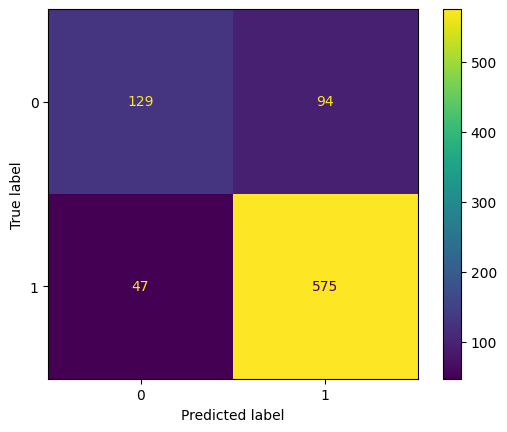

In [20]:
# Veamos la matriz de confusión

print(f'tn, fp, fn, tp = {confusion_matrix(y_test, y_pred_sv).ravel()}')
# más 'bonita'
conf = confusion_matrix(y_test, y_pred_sv)
ConfusionMatrixDisplay(conf).plot()
print(f'Val_accuracy_svm= {100*svm.score(X_test, y_test)} %')

In [21]:
print(classification_report(y_test, svm.predict(X_test), digits=4))

              precision    recall  f1-score   support

           0     0.7330    0.5785    0.6466       223
           1     0.8595    0.9244    0.8908       622

    accuracy                         0.8331       845
   macro avg     0.7962    0.7515    0.7687       845
weighted avg     0.8261    0.8331    0.8263       845



In [22]:
#Frase nueva:
frase = "Why should trust scientists with global warming if they didnt know Pluto wasnt a planet"
print(frase)


Why should trust scientists with global warming if they didnt know Pluto wasnt a planet


In [23]:
#Normalización de la frase nueva
frase = normalizacion(frase)

In [24]:
#Eliminación de las stops words
frase = ' '.join([palabra for palabra in frase.split() if palabra not in (stopWords)])

#Aplicación de stemming
frase =  ' '.join([stemmer.stem(palabra) for palabra in frase.split(' ')])

#Lematización
frase = ' '.join([lemmatizer.lemmatize(palabra) for palabra in frase.split(' ')])
print (frase)


trust scientist global warm didnt know pluto wasnt planet


In [25]:
prediccion = svm.predict([frase])
print(prediccion)
if(prediccion[0]==0):
    print(">> No cree en el calentamiento climático...")
else:
    print(">> Cree en el calentamiento climático...")


[0]
>> No cree en el calentamiento climático...
